### Retrieve Google earth engine data to your own storage
This notebook shows an example of how to retrieve data using Google earth engine and store it in a user defined output folder using `geemap`.  
The cloud storage folder can be used to store files retrieved in a workflow.    
This sample code will store the files to `param_shared_cloud_storage_folder` / `param_google_earth_engine_folder`.

#### Set up a google earth engine project
1) Set up a project at https://console.cloud.google.com

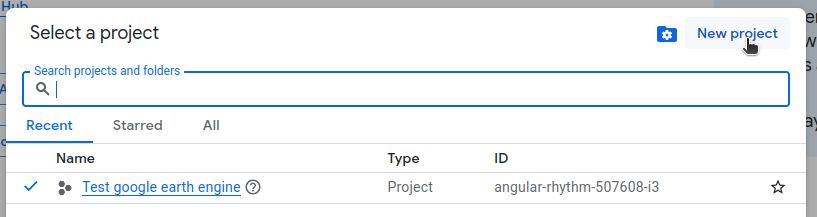

2) Set up a service account for the project https://console.cloud.google.com/iam-admin/serviceaccounts

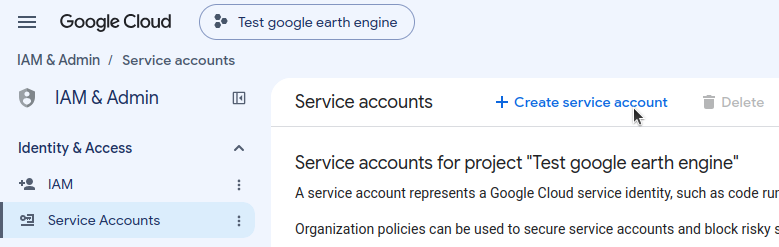

3) Create a JSON key from this same page for the service account

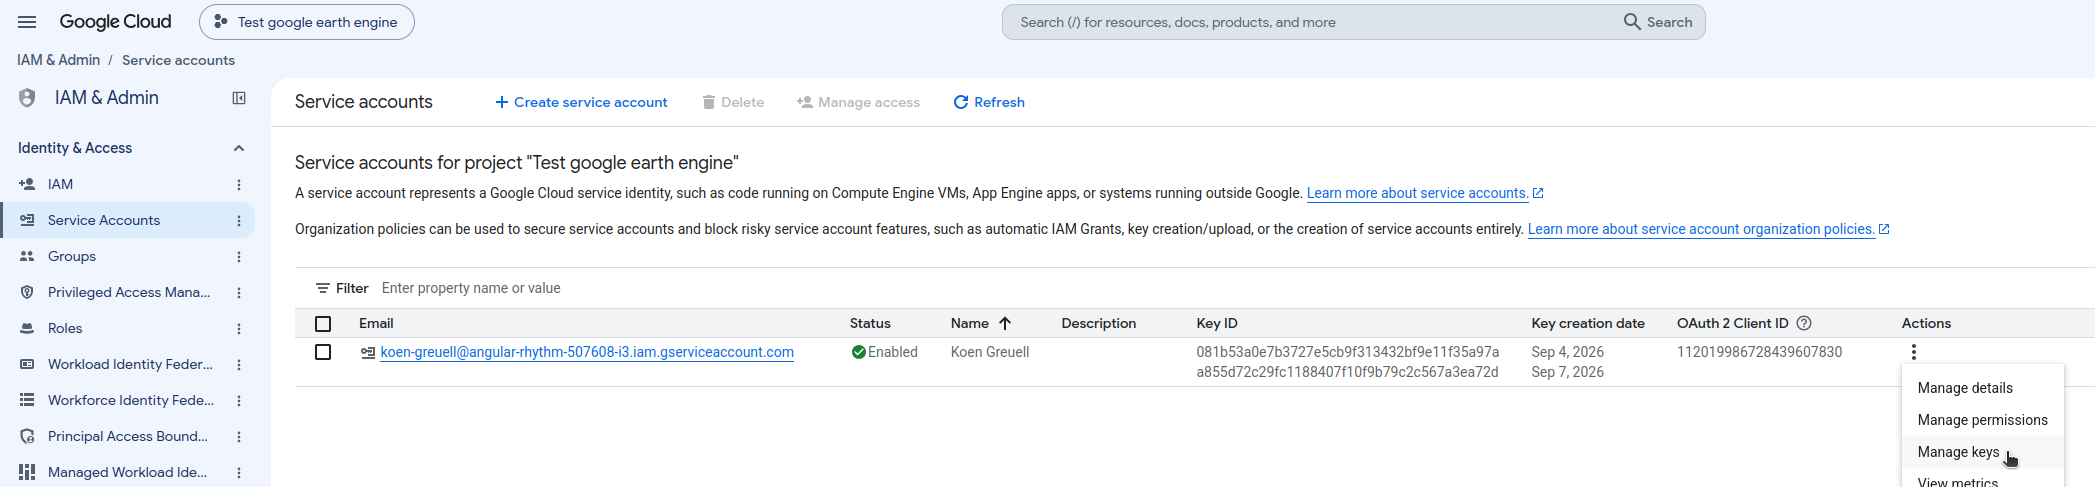

4) Move the JSON key to your personal cloud storage (see `param_personal_cloud_storage_folder`) and match the name of the file to `param_google_earth_engine_private_key_file`

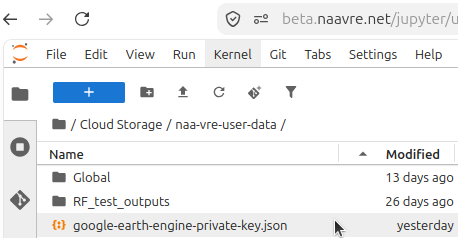

5) Give the service account the role `Service usage consumer` and `Earthengine Editor` https://console.cloud.google.com/iam-admin/iam. Make sure this role is given to the service account, not another user with a similar name.

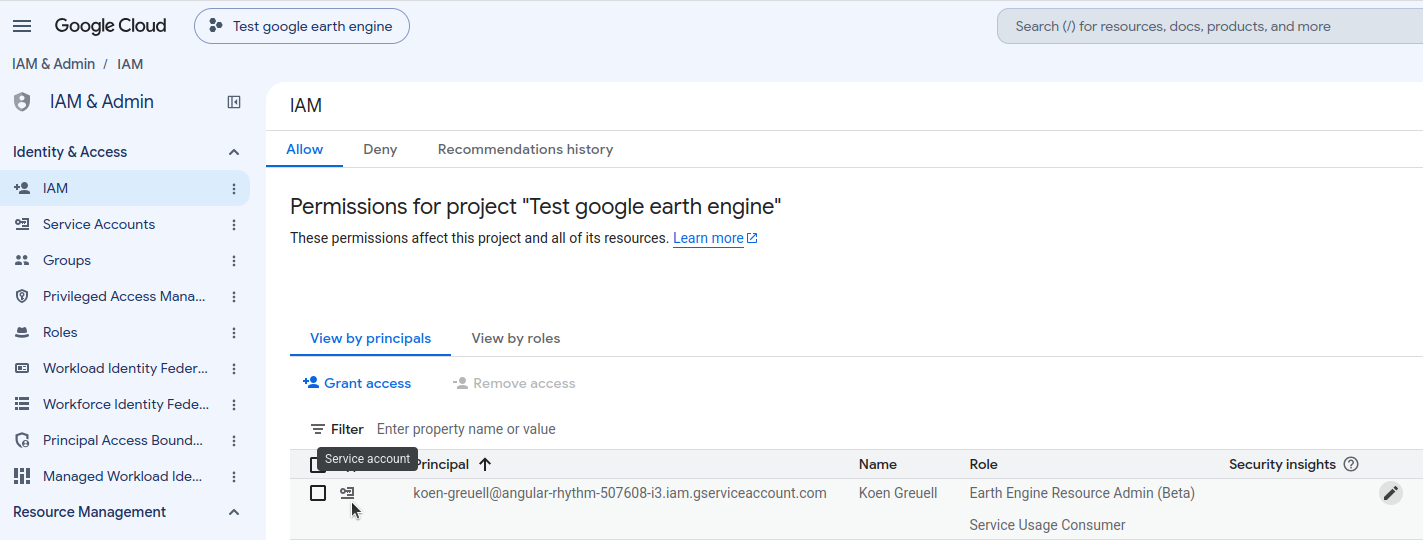

#### Documentation
See geemap documentation: https://geemap.org/notebooks/11_export_image/

In [ ]:
!pip install earthengine-api
!pip install geemap

In [ ]:
# Storage parameters
param_shared_cloud_storage_folder = '/home/jovyan/Cloud Storage/naa-vre-user-data'
param_personal_cloud_storage_folder = '/home/jovyan/Cloud Storage/naa-vre-user-data'
param_google_earth_engine_private_key_file = 'google-earth-engine-private-key.json'
param_google_earth_engine_project_id = 'angular-rhythm-507608-i3'
param_service_account = 'koen-greuell@angular-rhythm-507608-i3.iam.gserviceaccount.com'
param_google_earth_engine_folder = "google_earth_engine_files"

# Query parameters
param_areas = ["JOH", "LOS", "ADD", "ND"]
param_date_start = "2018-01-01"
param_date_end = "2020-01-01"

# Configuration
conf_johannesburg = {
    "latitude": -26.2044,
    "longitude": 28.0456
}
conf_lagos = {
    "latitude": 6.4561,
    "longitude": 3.3936
}
conf_addis_ababa = {
    "latitude": 9.0358,
    "longitude": 38.7525
}
conf_north_dakota = {
    "latitude": 46.7816,
    "longitude": -99.2222
}
conf_areas = {
    "JOH": conf_johannesburg,
    "LOS": conf_lagos,
    "ADD": conf_addis_ababa,
    "ND": conf_north_dakota
}

In [ ]:
# Earth engine initializer
'''
Suggested procedure:
- Read area IDs from shapefile.
- If test-run, set 2 small areas.
- Check which areas are in cloud storage.
- List areas that are not retrieved
'''
areas_to_retrieve = param_areas

In [ ]:
# GEE retriever
'''
Retrieves files from google earth engine to cloud storage
'''
import ee
import geemap
from pathlib import Path
import warnings

def authenticate_GEE():
    private_key_path = Path(param_personal_cloud_storage_folder) / param_google_earth_engine_private_key_file
    credentials=ee.ServiceAccountCredentials(param_service_account, str(private_key_path))
    ee.Initialize(credentials, project=param_google_earth_engine_project_id)

def retrieve_non_climatic_environmental_variables(area_code: str) -> str:
    warnings.warn("DUMMY FUNCTION: to be implemented")
    coordinates_area = conf_areas.get(area_code)
    area_loc = ee.Geometry.Point(coordinates_area.get("longitude"), coordinates_area.get("latitude"))
    image_collection = (
        ee.ImageCollection("USDA/NAIP/DOQQ")
        .filterBounds(area_loc)
        .filterDate(param_date_start, param_date_end)
        .filter(ee.Filter.listContains("system:band_names", "N"))
    )
    geemap.ee_export_image_collection(image_collection, scale=30, out_dir=str(Path(param_shared_cloud_storage_folder) / param_google_earth_engine_folder))
    return area_code

authenticate_GEE()
retrieved_areas = []
for area_code in areas_to_retrieve:
    area_retrieved = retrieve_non_climatic_environmental_variables(area_code)
    retrieved_areas.append(area_retrieved)

In [ ]:
# GEE retrieval completed
print(f"The following areas have been retrieved from GEE: {retrieved_areas}")

### Known errors
#### EEException: Permission 'earthengine.computations.create' denied on resource 'projects/[project ID]' (or it may not exist).
This error has occured with a service account with the role `Service usage consumer` but not the role `Earthengine Editor`.
Suggested solution: Give the service account the role `Earthengine Editor`.

#### Permission 'earthengine.thumbnails.create' denied on resource 'projects/angular-rhythm-507608-i3' (or it may not exist).
This error has occured with a service account with the role `Earth engine resource viewer` instead of the role  `Earthengine Editor`.
Suggested solution: Give the service account the role `Earthengine Editor`.
